### **Maestrıa en Ciencias de Datos**
### **Examen 1 - Matematicas Aplicadas en Ciencia de Datos**
### **Profesor: Diego Fernando Fonseca Valero**

#### **Integrantes:**

| **Nombres** | **Codigo Estudiante** | **Cedula** |
|----------|----------|----------|
|Eduardo Andres Piñeros Manjarres  | 1000269688  | 1067841294  |
|Natalia Ceballos Posada           | 1000270186  | 1034987681  |


In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

### **Ejercicio 1**

In [2]:
### Datos Tecnicos

## Matriz de Codificacion (A)
a = sp.symbols('a')
A = sp.Matrix([
    [1, 2, 1],
    [a, 4, 1],
    [2, 1, 3]
])

## Tabla de Conversion (Alfabeto)
tabla = {
 1: 'A',
 2: 'B',
 3: 'C',
 4: 'D',
 5: 'E',
 6: 'F',
 7: 'G',
 8: 'H',
 9: 'I',
 10: 'J',
 11: 'K',
 12: 'L',
 13: 'M',
 14: 'N',
 15: 'O',
 16: 'P',
 17: 'Q',
 18: 'R',
 19: 'S',
 20: 'T',
 21: 'U',
 22: 'V',
 23: 'W',
 24: 'X',
 25: 'Y',
 26: 'Z',
 27: ' '
 }

## La Transmision Interceptada (Vectores y)
y = sp.Matrix([
    [56, 67, 103],
    [54, 11, 117],
    [77, 55, 136],
    [70, 95, 110],
    [87, 77, 136],
    [96, 111, 138]
    ])

(a) Plantee una ecuacion matematica que relacione el determinante de A con el factor de volumen dado

Ecuacion : **det(A) = 15**

In [3]:
### (b) Resuelva dicha ecuacion para encontrar el valor de α.

alpha = sp.solve(sp.Eq(A.det(),15)) 

print(f'Valor de alpha: {alpha}')

Valor de alpha: [-8/5]


(c) Justifique: ¿Por qu ́e es necesario que el determinante sea diferente de cero para que esta mision de recuperacion tenga ́exito? ¿Que pasarıa geometricamente con el mensaje si det(A) = 0?


**Si el determinante de A es distinto de 0, significa que A tiene inversa y que la transformación si se puede hacer. Es decir $A^{-1}$ existe, por lo que $x = A^{-1}y$ se puede hacer.**

**En cambio si el determinante es 0, significa que la función ya no sería inyectiva, múltiples mensajes originales podrían producir el mismo vector cifrado $y = Ax$.**

**La información se perdería y no existiría una única matriz inversa $A^{-1}$ con la cual recuperar $x = A^{-1}y$. El descifrado sería ambiguo, o imposible.**

In [4]:
## Calcule el determinante para verificar que coincide con la pista de los metadatos.

A2= A.subs(a,alpha[0])

print('Matriz con nuevo valor de alpha \n')
sp.pprint(A2)

det = A2.det()
print(f'\nDetermninante nueva matriz: {det}')


Matriz con nuevo valor de alpha 

⎡ 1    2  1⎤
⎢          ⎥
⎢-8/5  4  1⎥
⎢          ⎥
⎣ 2    1  3⎦

Determninante nueva matriz: 15


In [5]:
## Matriz inversa
inversa = A2.inv()
print('Inversa: \n')
sp.pprint(inversa)

Inversa: 

⎡ 11              ⎤
⎢ ──   -1/3  -2/15⎥
⎢ 15              ⎥
⎢                 ⎥
⎢ 34         -13  ⎥
⎢ ──   1/15  ──── ⎥
⎢ 75          75  ⎥
⎢                 ⎥
⎢-16          12  ⎥
⎢────  1/5    ──  ⎥
⎣ 25          25  ⎦


In [6]:
## Operacion de Descifrado Vectores
messages = []
for i in range(y.shape[0]):
    fila = y.row(i)
    solutions = A2.solve(fila.T)
    print(f'Solucion Vector y{i+1}:\n')
    print(f'{solutions} \n')
    message = map(lambda x: tabla[round(x)],solutions)
    messages.extend(list(message))



Solucion Vector y1:

Matrix([[5], [12], [27]]) 

Solucion Vector y2:

Matrix([[61/3], [74/15], [119/5]]) 

Solucion Vector y3:

Matrix([[20], [15], [27]]) 

Solucion Vector y4:

Matrix([[5], [19], [27]]) 

Solucion Vector y5:

Matrix([[20], [21], [25]]) 

Solucion Vector y6:

Matrix([[15], [27], [27]]) 



In [7]:
## Resultado
print(''.join(messages))

EL TEXTO ES TUYO  


### **Ejecrcicio 2**

In [8]:
# Matriz de Transicion 
P = np.array([
    [0.95, 0.05, 0, 0, 0, 0, 0],
    [0.4, 0.3, 0.3, 0, 0, 0, 0],
    [0, 0.45, 0.1, 0.45, 0, 0, 0],
    [0, 0, 0.4, 0.2, 0.4, 0, 0],
    [0, 0, 0, 0.45, 0.1, 0.45, 0],
    [0, 0, 0, 0, 0.3, 0.3, 0.4],
    [0, 0, 0, 0, 0, 0.05, 0.95],
])

In [9]:
## 1. Caminata Aleatoria
n_simulaciones = 8
pasos = 100
estado_inicial = 3  # índice del estado 4
trayectorias = []

for sim in range(n_simulaciones):
    estado = estado_inicial
    camino = [estado + 1]  
    for _ in range(pasos):
        estado = np.random.choice(len(P), p=P[estado])
        camino.append(estado + 1)
    trayectorias.append(camino)

# Frecuencia de estados 
todos_los_estados = np.concatenate([np.array(camino) for camino in trayectorias]) - 1
frecuencias = np.bincount(todos_los_estados, minlength=P.shape[0]).astype(float)
frecuencias_relativas = frecuencias / frecuencias.sum()

print("Frecuencia relativa por estado:")
for e, fr in enumerate(frecuencias_relativas, start=1):
    print(f"Estado {e}: {fr:.4f}")


Frecuencia relativa por estado:
Estado 1: 0.2735
Estado 2: 0.0557
Estado 3: 0.0359
Estado 4: 0.0495
Estado 5: 0.0520
Estado 6: 0.0730
Estado 7: 0.4604


**Tendecias Observadas:**

A pesar de comenzar siempre en un estado neutral, después de 100 pasos las trayectorias se concentran mayoritariamente en los extremos (estado 1 y estado 7), con muy poca probabilidad en los estados intermedios. Esto ocurre porque los estados 1 y 7 tienen una probabilidad alta (0.95) de quedarse en el mismo estado, mientras que los estados intermedios tienden a moverse rápidamente hacia uno de los dos extremos. Es decir, un cliente neutral tiende a quedar muy insatisfecho o muy satisfecho, y rara vez se queda en un estado intermedio.

In [10]:
## 2. Distribucion Estacionaria, a donde tiende

# Metodo 1: vector propio de P^T asociado al valor propio 1
valores_propios, vectores_propios = np.linalg.eig(P.T)
idx = np.argmin(np.abs(valores_propios - 1))
pi_estacionaria = np.real(vectores_propios[:, idx])
pi_estacionaria = pi_estacionaria / pi_estacionaria.sum()
print("Distribucion estacionaria (via valores/vectores propios):")
print(np.round(pi_estacionaria, 4))

# Metodo 2: vector propio de P^T asociado al valor propio 1
pi0 = np.zeros(7); pi0[3] = 1.0  
pi_n = pi0.copy()
for _ in range(1000):
    pi_n = pi_n @ P
    
print("\nDistribucion estacionaria (via iteracion de potencias, 1000 pasos):")
print(np.round(pi_n, 4))

Distribucion estacionaria (via valores/vectores propios):
[0.3983 0.0498 0.0332 0.0373 0.0332 0.0498 0.3983]

Distribucion estacionaria (via iteracion de potencias, 1000 pasos):
[0.3983 0.0498 0.0332 0.0373 0.0332 0.0498 0.3983]


Ambos métodos coinciden y confirman numéricamente lo observado en la simulación, la distribución estacionaria concentra cerca del 40% de la probabilidad en el estado 1, 40% en el estado 7, y menos del 20% repartido en los estados 2 a 6. Esto valida, desde el álgebra lineal, la tendencia a los extremos.

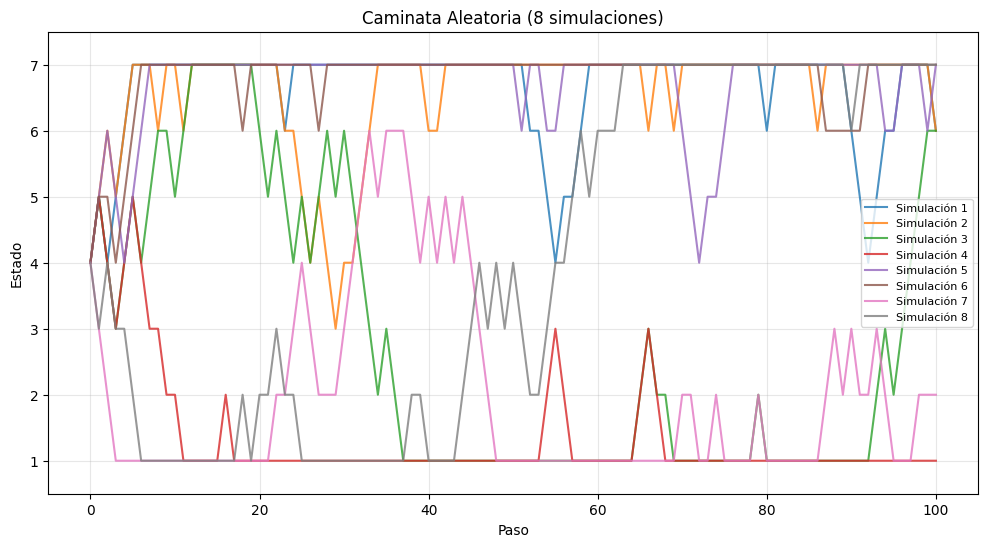

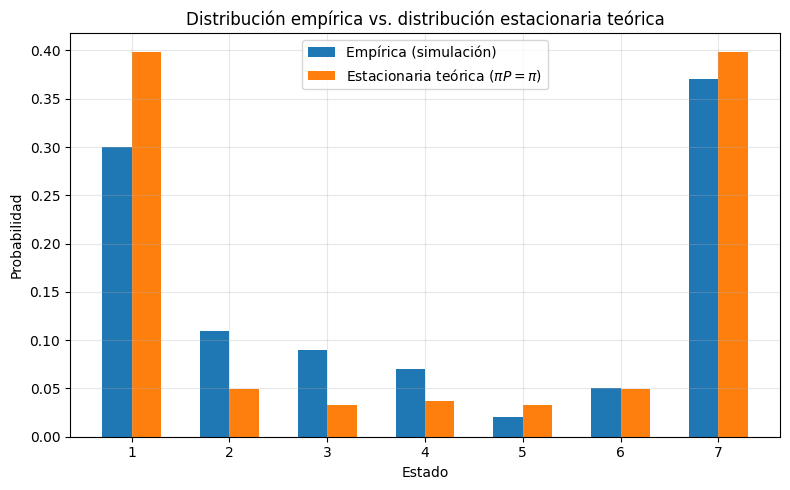

In [11]:
## Visualizacion 

fig, ax = plt.subplots(figsize=(12, 6))
for i, camino in enumerate(trayectorias, start=1):
    ax.plot(camino, alpha=0.8, linewidth=1.5, label=f"Simulación {i}")

ax.set_title("Caminata Aleatoria (8 simulaciones)")
ax.set_xlabel("Paso")
ax.set_ylabel("Estado")
ax.set_ylim(0.5, 7.5)
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=8)
plt.show()


estados = np.arange(1, 8)
estados_finales = trayectorias[-1]

frecuencia_empirica = np.array([np.sum(estados_finales == e) for e in estados]) / 100

fig2, ax2 = plt.subplots(figsize=(8, 5))

ax2.bar(estados - 0.15, frecuencia_empirica, width=0.3, label="Empírica (simulación)")
ax2.bar(estados + 0.15, pi_estacionaria, width=0.3, label="Estacionaria teórica ($\\pi P=\\pi$)")

ax2.set_xlabel("Estado")
ax2.set_ylabel("Probabilidad")
ax2.set_title("Distribución empírica vs. distribución estacionaria teórica")
ax2.set_xticks(estados)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()



### Descripcion Esquematica

El proceso es una cadena de Markov discreta de primer orden: el estado del cliente en el paso $t+1$ solo depende del estado en el paso $t$, y no de todo su historial.

- El estado del sistema en el paso $n$ se representa como una distribución de probabilidad $\pi_n \in \mathbb{R}^7$, con $\sum_i \pi_n(i) = 1$.
- La dinámica se rige por la ecuación lineal $\pi_{n+1} = \pi_n P$, donde $P$ es la matriz de transición.
- Iterando, $\pi_n = \pi_0 P^n$: el comportamiento a largo plazo es literalmente una potencia de matriz, y su límite quedó determinado por el vector propio izquierdo de $P$ asociado al valor propio dominante $\lambda_1=1$.
- Cada paso de la caminata aleatoria consiste en muestrear la fila de $P$ correspondiente al estado actual (np.random.choice(7, p=P[estado])), que es exactamente la operación de aplicar la matriz de transición a un vector que representa el estado actual. Al promediar sobre muchas repeticiones, la fracción de simulaciones en cada estado converge al vector $\pi_n = \pi_0 P^n$, y se calculó la distribución estacionaria como vector propio de $P^\top$ (equivalente a resolver $\pi(P-I)=0$).

### **Ejercicio 3**


In [12]:
img = Image.open(r'..\Imagen\gato_imagen.jpg').convert("L")
X0 = np.array(img)      

alpha = 0.8
tol = 1e-4
max_iter = 5000

def proceso_iterativo(X0, alpha=0.8, tol=1e-4, max_iter=5000):
    X = X0.astype(np.float64, copy=True)
    errores = []

    for n in range(max_iter):
        padded = np.pad(X, pad_width=1, mode="edge")

        arriba = padded[:-2, 1:-1]
        abajo = padded[2:, 1:-1]
        izq = padded[1:-1, :-2]
        der = padded[1:-1, 2:]

        X_next = alpha * X + ((1 - alpha) / 4.0) * (arriba + abajo + izq + der)

        err = np.max(np.abs(X_next - X))
        errores.append(err)

        X = X_next

        if err < tol:
            break

    return X, np.asarray(errores)

X_suavizada, errores = proceso_iterativo(X0, alpha=alpha, tol=tol, max_iter=max_iter)

# Bordes
bordes = np.clip(np.abs(X_suavizada - X0), 0, 255).astype(np.uint8)


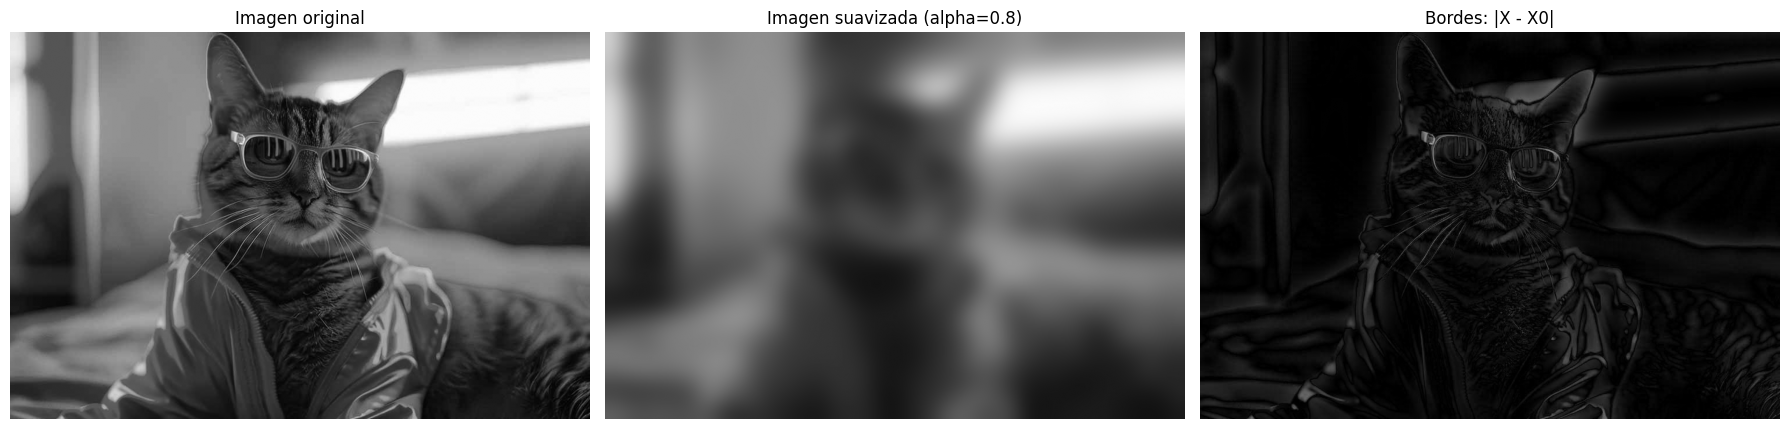

In [13]:
## Visualizacion

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(X0, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(X_suavizada, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Imagen suavizada (alpha={alpha})")
axes[1].axis("off")

axes[2].imshow(bordes, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Bordes: |X - X0|")
axes[2].axis("off")

plt.tight_layout()
plt.show()

La actualización es un promedio ponderado entre el pixel actual y sus 4 vecinos

- alpha cercano a 1 -> conserva más el valor actual, suavizado suave.
- alpha cercano a 0 -> el pixel se acerca más rápido al promedio de vecinos, imagen más borrosa.

a imagen con bordes se obtiene como la diferencia entre la imagen suavizada y la original |X_k - X_0|

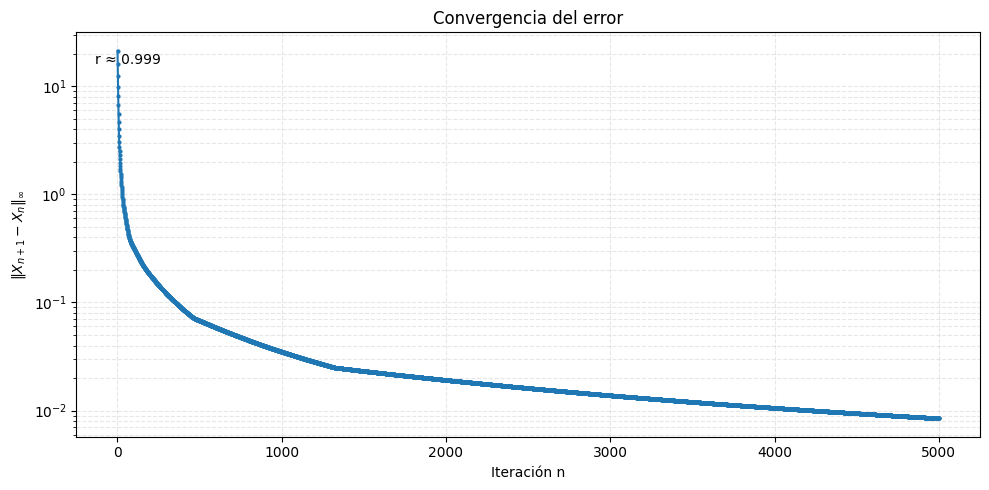

In [14]:
## Error en funcion iteracion

fig2, ax = plt.subplots(figsize=(10, 5))
it = np.arange(1, len(errores) + 1)
ax.plot(it, errores, "o-", color="tab:blue", lw=1.5, ms=2)
ax.set_yscale("log")
ax.set_title("Convergencia del error")
ax.set_xlabel("Iteración n")
ax.set_ylabel(r"$\|X_{n+1}-X_n\|_\infty$")
ax.grid(True, which="both", ls="--", alpha=0.3)

# Estimación de tasa de convergencia
if len(errores) > 20:
    ventana = errores[10:]
    x = np.arange(len(ventana))
    coef = np.polyfit(x, np.log(ventana + 1e-300), 1)
    pendiente = coef[0]
    tasa = np.exp(pendiente)
    ax.text(0.02, 0.95, f"r ≈ {tasa:.3f}", transform=ax.transAxes, va="top", fontsize=10)

plt.tight_layout()
plt.show()


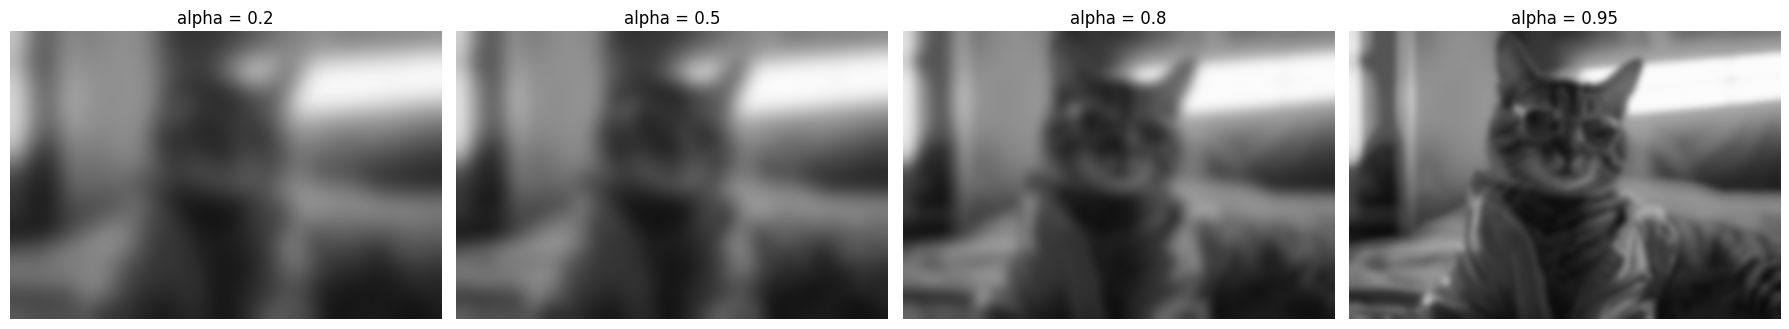

In [15]:
# Distintos valores de alpha
alphas = [0.2, 0.5, 0.8, 0.95]
fig3, axes3 = plt.subplots(1, len(alphas), figsize=(18, 5))

for ax, a in zip(axes3, alphas):
    X_a, err_a = proceso_iterativo(X0, alpha=a, tol=1e-4, max_iter=2000)
    ax.imshow(X_a, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"alpha = {a}")
    ax.axis("off")

plt.tight_layout()
plt.show()

**Analisis**

Como la actualización es lineal con una matriz de promedio ponderado, la diferencia entre dos iteraciones satisface una ecuación del tipo $e_{k+1} = M e_k$ donde M tiene valores con magnitud menor que 1. Por eso, la convergencia es geométrica $||e_k|| ≤ C * r^k,   0 < r < 1$ lo que corresponde a una tasa exponencial. Esto es consistente con la gráfica en escala logarítmica, que debería verse aproximadamente lineal.